In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("student_performance_dataset_v2.csv")

df.head()

,Study_Hours_per_Week,Attendance_Percentage,Previous_Exam_Score,Assignments_Completed,Sleep_Hours_per_Night,Internet_Access,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,16.98,85.89,83.19,8,5.92,No,No,61.17,Pass
1,13.17,100.00,74.64,5,6.61,Yes,Yes,59.84,Pass
2,17.89,51.02,59.07,4,5.77,Yes,No,69.43,Pass
3,23.14,80.44,46.36,6,6.40,Yes,Yes,53.41,Pass
4,12.60,62.24,70.57,6,4.34,Yes,No,48.80,Fail


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (500, 9)

Column Names:
['Study_Hours_per_Week', 'Attendance_Percentage', 'Previous_Exam_Score', 'Assignments_Completed', 'Sleep_Hours_per_Night', 'Internet_Access', 'Extracurricular_Activities', 'Final_Exam_Score', 'Pass_Fail']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Study_Hours_per_Week        500 non-null    float64
 1   Attendance_Percentage       500 non-null    float64
 2   Previous_Exam_Score         500 non-null    float64
 3   Assignments_Completed       500 non-null    int64  
 4   Sleep_Hours_per_Night       500 non-null    float64
 5   Internet_Access             500 non-null    object 
 6   Extracurricular_Activities  500 non-null    object 
 7   Final_Exam_Score            500 non-null    float64
 8   Pass_Fail                   500 non-null    object 
dty

In [4]:
# Check missing values 

df.describe(include="all")

,Study_Hours_per_Week,Attendance_Percentage,Previous_Exam_Score,Assignments_Completed,Sleep_Hours_per_Night,Internet_Access,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
count,500.000000,500.000000,500.000000,500.000000,500.000000,500,500,500.000000,500
unique,NaN,NaN,NaN,NaN,NaN,2,2,NaN,2
top,NaN,NaN,NaN,NaN,NaN,Yes,No,NaN,Pass
freq,NaN,NaN,NaN,NaN,NaN,404,262,NaN,383
mean,14.056600,72.323360,59.928800,6.022000,6.788320,NaN,NaN,60.237760,NaN
std,5.818451,14.267363,18.051955,2.337615,1.225766,NaN,NaN,13.224797,NaN
min,1.000000,35.000000,10.000000,0.000000,4.000000,NaN,NaN,13.930000,NaN
25%,9.797500,63.067500,47.160000,4.000000,5.940000,NaN,NaN,51.352500,NaN
50%,14.080000,72.425000,60.155000,6.000000,6.795000,NaN,NaN,60.130000,NaN
75%,17.817500,81.767500,71.585000,8.000000,7.670000,NaN,NaN,69.477500,NaN


In [5]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


In [6]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (500, 9)


In [7]:
print("Pass/Fail Distribution:")
print(df["Pass_Fail"].value_counts())

print("\nPercentage Distribution:")
print((df["Pass_Fail"].value_counts(normalize=True) * 100).round(2))

Pass/Fail Distribution:
Pass_Fail
Pass    383
Fail    117
Name: count, dtype: int64

Percentage Distribution:
Pass_Fail
Pass    76.6
Fail    23.4
Name: proportion, dtype: float64


EDA

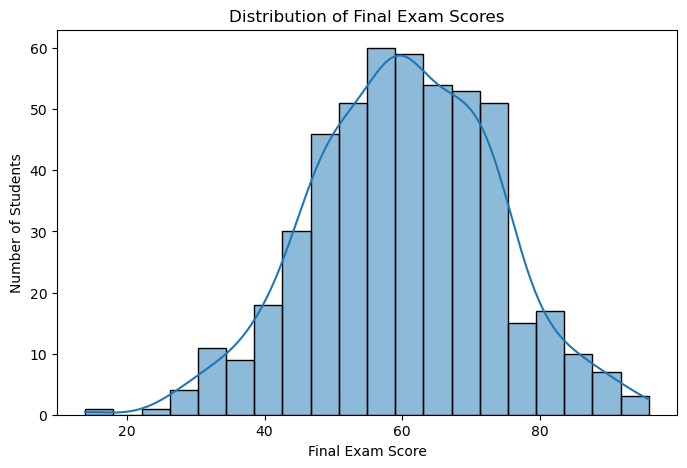

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Final_Exam_Score"], bins=20, kde=True)

plt.title("Distribution of Final Exam Scores")
plt.xlabel("Final Exam Score")
plt.ylabel("Number of Students")

plt.show()

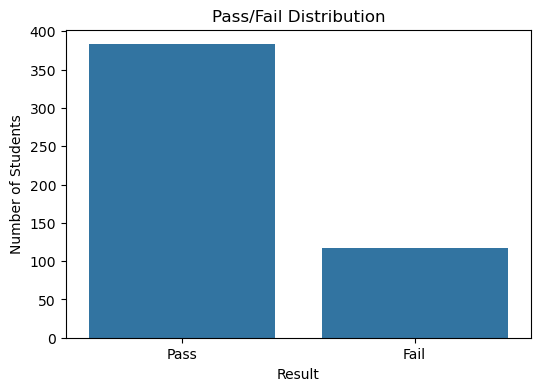

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Pass_Fail")

plt.title("Pass/Fail Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.show()

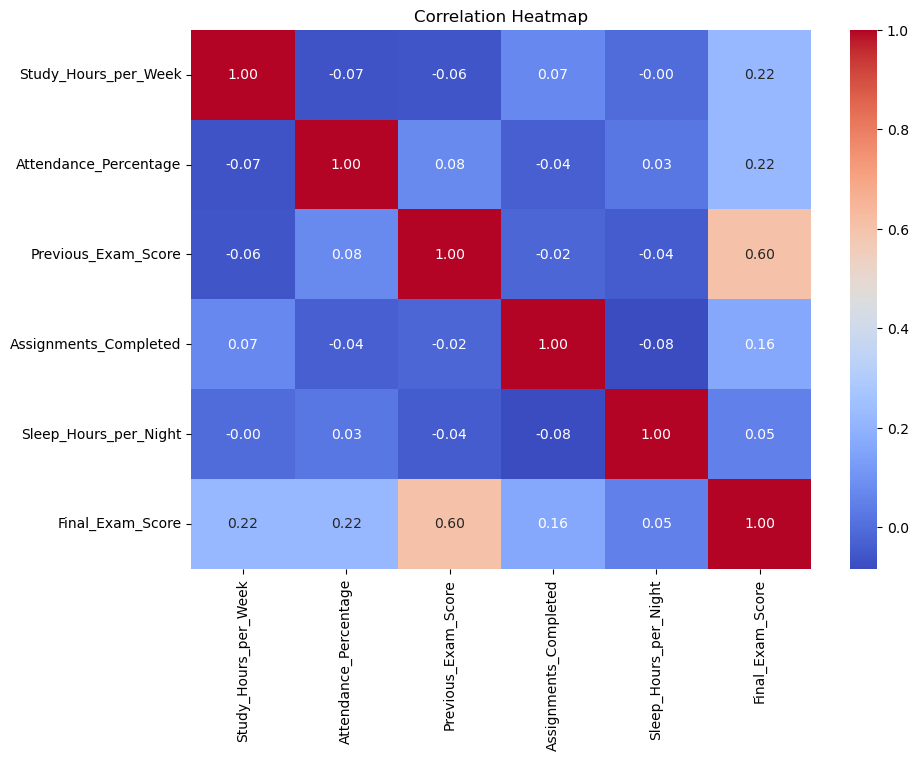

In [10]:
plt.figure(figsize=(10, 7))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

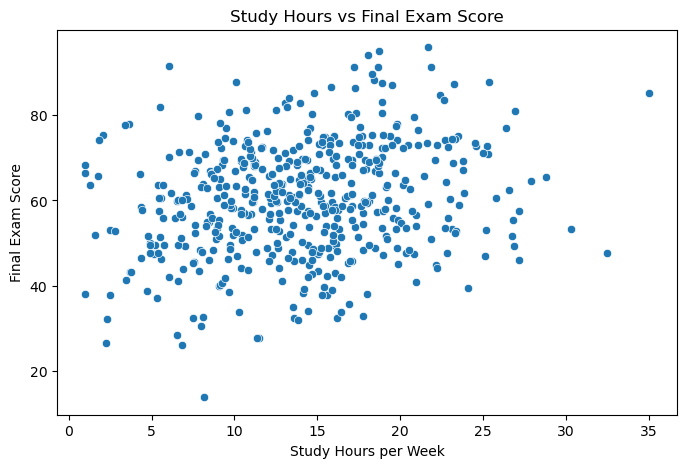

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Study_Hours_per_Week",
    y="Final_Exam_Score"
)

plt.title("Study Hours vs Final Exam Score")
plt.xlabel("Study Hours per Week")
plt.ylabel("Final Exam Score")

plt.show()

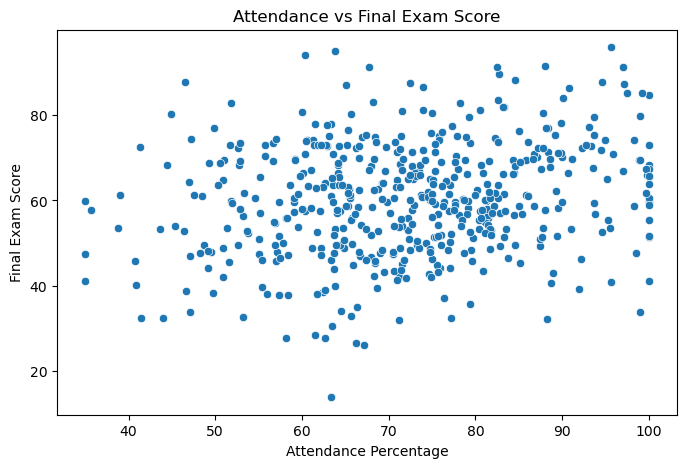

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Attendance_Percentage",
    y="Final_Exam_Score"
)

plt.title("Attendance vs Final Exam Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Final Exam Score")

plt.show()

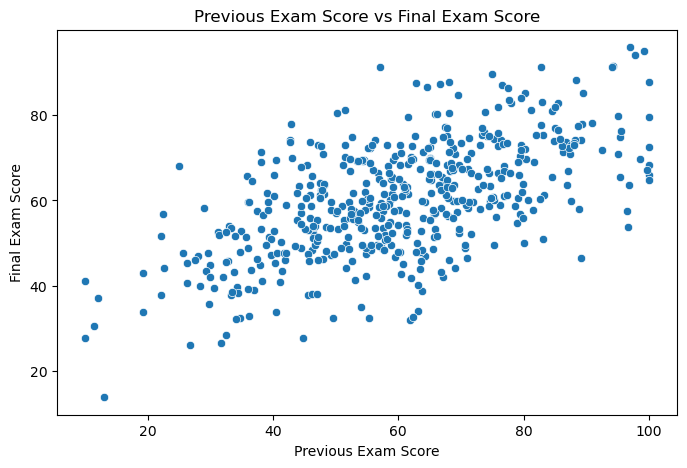

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Previous_Exam_Score",
    y="Final_Exam_Score"
)

plt.title("Previous Exam Score vs Final Exam Score")
plt.xlabel("Previous Exam Score")
plt.ylabel("Final Exam Score")

plt.show()

Regression Data Preprocessing

In [14]:
X = df.drop(columns=["Final_Exam_Score", "Pass_Fail"])
y = df["Final_Exam_Score"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Study_Hours_per_Week', 'Attendance_Percentage', 'Previous_Exam_Score', 'Assignments_Completed', 'Sleep_Hours_per_Night', 'Internet_Access', 'Extracurricular_Activities']

Target:
Final_Exam_Score


In [16]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,Study_Hours_per_Week,Attendance_Percentage,Previous_Exam_Score,Assignments_Completed,Sleep_Hours_per_Night,Internet_Access_Yes,Extracurricular_Activities_Yes
0,16.98,85.89,83.19,8,5.92,False,False
1,13.17,100.00,74.64,5,6.61,True,True
2,17.89,51.02,59.07,4,5.77,True,False
3,23.14,80.44,46.36,6,6.40,True,True
4,12.60,62.24,70.57,6,4.34,True,False


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (400, 7)
Testing Data Shape: (100, 7)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Linear Regression

In [19]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

In [20]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_linear = mean_absolute_error(y_test, y_pred_linear)

mse_linear = mean_squared_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(mse_linear)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance:")
print("MAE:", round(mae_linear, 3))
print("MSE:", round(mse_linear, 3))
print("RMSE:", round(rmse_linear, 3))
print("R² Score:", round(r2_linear, 3))

Linear Regression Performance:
MAE: 6.767
MSE: 73.186
RMSE: 8.555
R² Score: 0.563


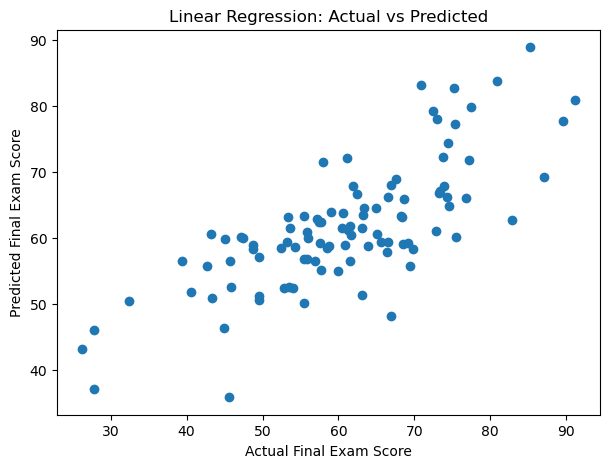

In [21]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred_linear)

plt.xlabel("Actual Final Exam Score")
plt.ylabel("Predicted Final Exam Score")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

Polynomial Regression

In [23]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print("Original Features:", X_train_scaled.shape[1])
print("Polynomial Features:", X_train_poly.shape[1])

Original Features: 7
Polynomial Features: 36


In [24]:
poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

In [25]:
mae_poly = mean_absolute_error(y_test, y_pred_poly)

mse_poly = mean_squared_error(y_test, y_pred_poly)

rmse_poly = np.sqrt(mse_poly)

r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression Performance:")
print("MAE:", round(mae_poly, 3))
print("MSE:", round(mse_poly, 3))
print("RMSE:", round(rmse_poly, 3))
print("R² Score:", round(r2_poly, 3))

Polynomial Regression Performance:
MAE: 6.89
MSE: 75.754
RMSE: 8.704
R² Score: 0.548


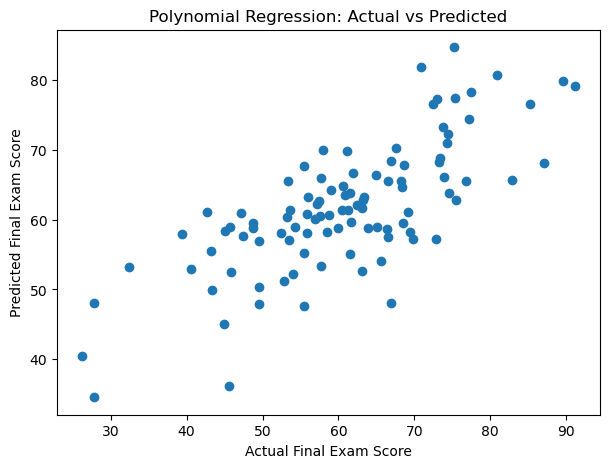

In [26]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred_poly)

plt.xlabel("Actual Final Exam Score")
plt.ylabel("Predicted Final Exam Score")
plt.title("Polynomial Regression: Actual vs Predicted")

plt.show()

Ridge Regression

In [27]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

In [28]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)

rmse_ridge = np.sqrt(mse_ridge)

r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Performance:")
print("MAE:", round(mae_ridge, 3))
print("MSE:", round(mse_ridge, 3))
print("RMSE:", round(rmse_ridge, 3))
print("R² Score:", round(r2_ridge, 3))

Ridge Regression Performance:
MAE: 6.765
MSE: 73.193
RMSE: 8.555
R² Score: 0.563


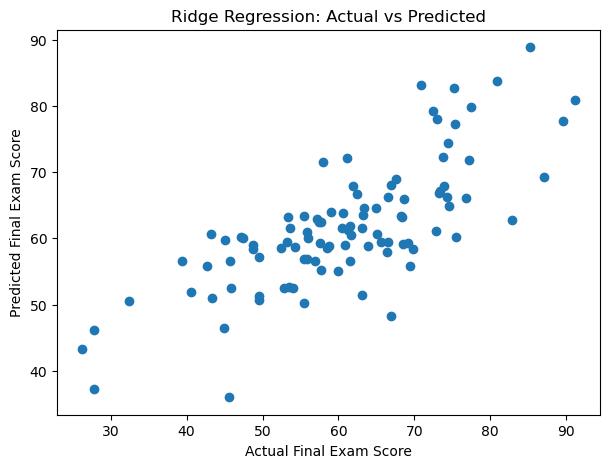

In [29]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred_ridge)

plt.xlabel("Actual Final Exam Score")
plt.ylabel("Predicted Final Exam Score")
plt.title("Ridge Regression: Actual vs Predicted")

plt.show()

Lasso Regression

In [30]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1, max_iter=10000)

lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

In [31]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)

rmse_lasso = np.sqrt(mse_lasso)

r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Performance:")
print("MAE:", round(mae_lasso, 3))
print("MSE:", round(mse_lasso, 3))
print("RMSE:", round(rmse_lasso, 3))
print("R² Score:", round(r2_lasso, 3))

Lasso Regression Performance:
MAE: 6.729
MSE: 72.848
RMSE: 8.535
R² Score: 0.565


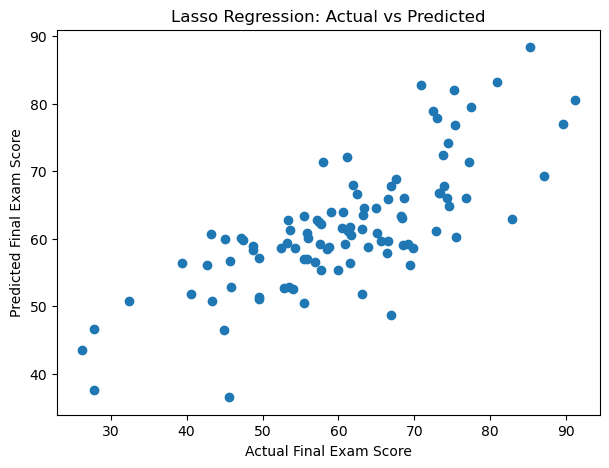

In [32]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred_lasso)

plt.xlabel("Actual Final Exam Score")
plt.ylabel("Predicted Final Exam Score")
plt.title("Lasso Regression: Actual vs Predicted")

plt.show()

Compare All Regression Models

In [33]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MAE": [
        mae_linear,
        mae_poly,
        mae_ridge,
        mae_lasso
    ],
    "MSE": [
        mse_linear,
        mse_poly,
        mse_ridge,
        mse_lasso
    ],
    "RMSE": [
        rmse_linear,
        rmse_poly,
        rmse_ridge,
        rmse_lasso
    ],
    "R2 Score": [
        r2_linear,
        r2_poly,
        r2_ridge,
        r2_lasso
    ]
})

regression_results.round(3)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,6.767,73.186,8.555,0.563
1,Polynomial Regression,6.890,75.754,8.704,0.548
2,Ridge Regression,6.765,73.193,8.555,0.563
3,Lasso Regression,6.729,72.848,8.535,0.565


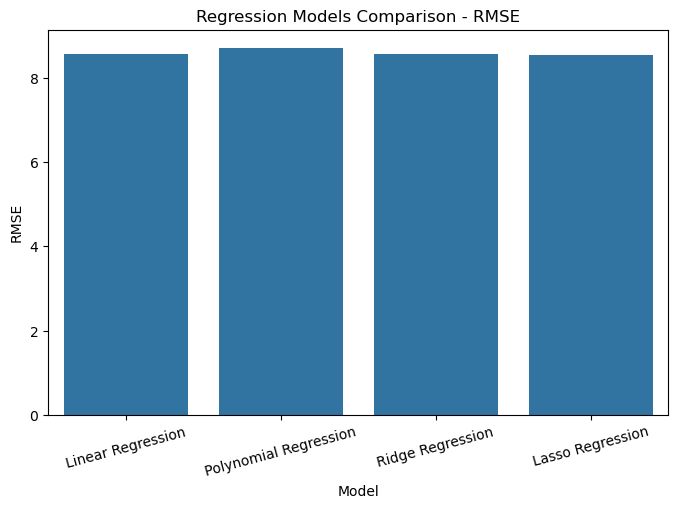

In [34]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=regression_results,
    x="Model",
    y="RMSE"
)

plt.title("Regression Models Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)

plt.show()

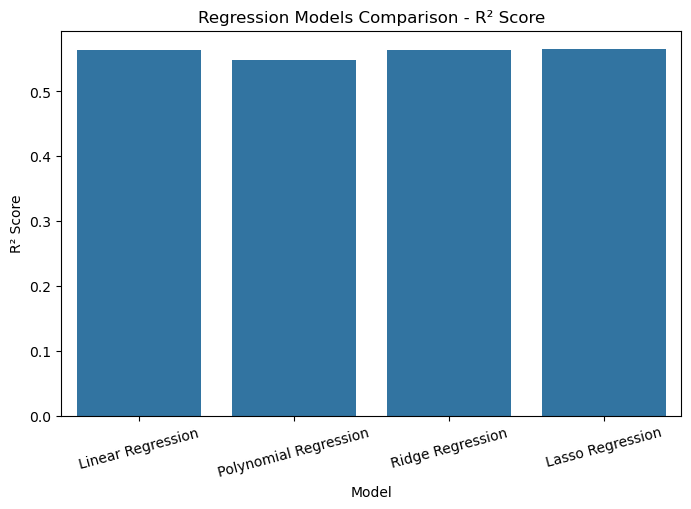

In [35]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=regression_results,
    x="Model",
    y="R2 Score"
)

plt.title("Regression Models Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)

plt.show()

In [36]:
best_regression_model = regression_results.loc[
    regression_results["R2 Score"].idxmax()
]

print("Best Regression Model:")
print(best_regression_model)

Best Regression Model:
Model       Lasso Regression
MAE                 6.728549
MSE                72.847893
RMSE                8.535098
R2 Score            0.565264
Name: 3, dtype: object


In [37]:
df["Pass_Fail"] = np.where(
    df["Final_Exam_Score"] >= 50,
    "Pass",
    "Fail"
)

df[["Final_Exam_Score", "Pass_Fail"]].head()

,Final_Exam_Score,Pass_Fail
0,61.17,Pass
1,59.84,Pass
2,69.43,Pass
3,53.41,Pass
4,48.80,Fail


Pass/Fail Distribution:
Pass_Fail
Pass    383
Fail    117
Name: count, dtype: int64


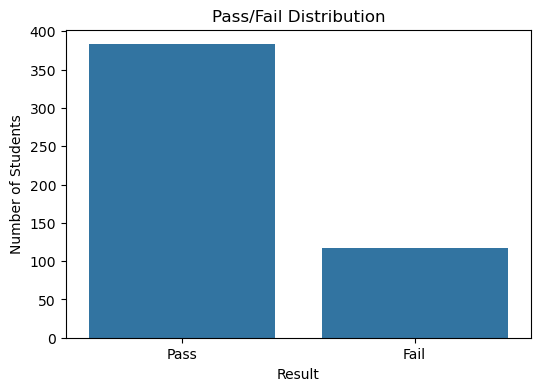

In [38]:
print("Pass/Fail Distribution:")
print(df["Pass_Fail"].value_counts())

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Pass_Fail")

plt.title("Pass/Fail Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.show()

Classification Data Preprocessing

In [39]:
X_class = df.drop(columns=["Final_Exam_Score", "Pass_Fail"])

y_class = df["Pass_Fail"]

print("Features:")
print(X_class.columns.tolist())

print("\nTarget Distribution:")
print(y_class.value_counts())

Features:
['Study_Hours_per_Week', 'Attendance_Percentage', 'Previous_Exam_Score', 'Assignments_Completed', 'Sleep_Hours_per_Night', 'Internet_Access', 'Extracurricular_Activities']

Target Distribution:
Pass_Fail
Pass    383
Fail    117
Name: count, dtype: int64


In [40]:
X_class = pd.get_dummies(X_class, drop_first=True)

X_class.head()

,Study_Hours_per_Week,Attendance_Percentage,Previous_Exam_Score,Assignments_Completed,Sleep_Hours_per_Night,Internet_Access_Yes,Extracurricular_Activities_Yes
0,16.98,85.89,83.19,8,5.92,False,False
1,13.17,100.00,74.64,5,6.61,True,True
2,17.89,51.02,59.07,4,5.77,True,False
3,23.14,80.44,46.36,6,6.40,True,True
4,12.60,62.24,70.57,6,4.34,True,False


In [41]:
from sklearn.model_selection import train_test_split

X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Training Data Shape:", X_class_train.shape)
print("Testing Data Shape:", X_class_test.shape)

Training Data Shape: (400, 7)
Testing Data Shape: (100, 7)


In [42]:
from sklearn.preprocessing import StandardScaler

class_scaler = StandardScaler()

X_class_train_scaled = class_scaler.fit_transform(X_class_train)
X_class_test_scaled = class_scaler.transform(X_class_test)

Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(
    X_class_train_scaled,
    y_class_train
)

y_pred_logistic = logistic_model.predict(
    X_class_test_scaled
)

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy_logistic = accuracy_score(
    y_class_test,
    y_pred_logistic
)

precision_logistic = precision_score(
    y_class_test,
    y_pred_logistic,
    pos_label="Pass"
)

recall_logistic = recall_score(
    y_class_test,
    y_pred_logistic,
    pos_label="Pass"
)

f1_logistic = f1_score(
    y_class_test,
    y_pred_logistic,
    pos_label="Pass"
)

print("Logistic Regression Performance:")
print("Accuracy:", round(accuracy_logistic, 3))
print("Precision:", round(precision_logistic, 3))
print("Recall:", round(recall_logistic, 3))
print("F1 Score:", round(f1_logistic, 3))

Logistic Regression Performance:
Accuracy: 0.84
Precision: 0.843
Recall: 0.974
F1 Score: 0.904


In [45]:
print(
    classification_report(
        y_class_test,
        y_pred_logistic
    )
)

              precision    recall  f1-score   support

        Fail       0.82      0.39      0.53        23
        Pass       0.84      0.97      0.90        77

    accuracy                           0.84       100
   macro avg       0.83      0.68      0.72       100
weighted avg       0.84      0.84      0.82       100



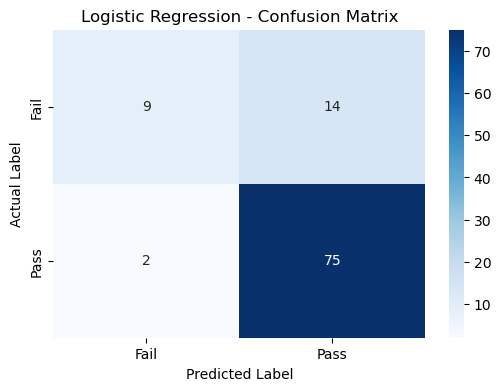

In [46]:
cm_logistic = confusion_matrix(
    y_class_test,
    y_pred_logistic,
    labels=["Fail", "Pass"]
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

KNN Classification

In [47]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(
    X_class_train_scaled,
    y_class_train
)

y_pred_knn = knn_model.predict(
    X_class_test_scaled
)

In [48]:
accuracy_knn = accuracy_score(
    y_class_test,
    y_pred_knn
)

precision_knn = precision_score(
    y_class_test,
    y_pred_knn,
    pos_label="Pass"
)

recall_knn = recall_score(
    y_class_test,
    y_pred_knn,
    pos_label="Pass"
)

f1_knn = f1_score(
    y_class_test,
    y_pred_knn,
    pos_label="Pass"
)

print("KNN Performance:")
print("Accuracy:", round(accuracy_knn, 3))
print("Precision:", round(precision_knn, 3))
print("Recall:", round(recall_knn, 3))
print("F1 Score:", round(f1_knn, 3))

KNN Performance:
Accuracy: 0.75
Precision: 0.795
Recall: 0.909
F1 Score: 0.848


In [49]:
print(
    classification_report(
        y_class_test,
        y_pred_knn
    )
)

              precision    recall  f1-score   support

        Fail       0.42      0.22      0.29        23
        Pass       0.80      0.91      0.85        77

    accuracy                           0.75       100
   macro avg       0.61      0.56      0.57       100
weighted avg       0.71      0.75      0.72       100



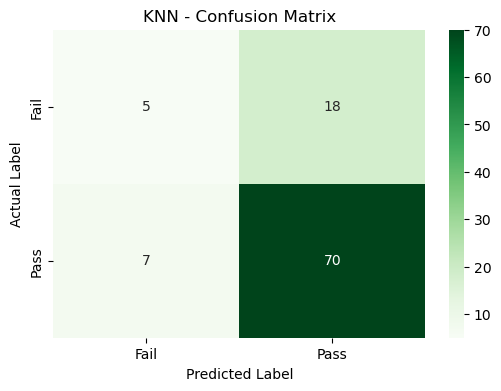

In [50]:
cm_knn = confusion_matrix(
    y_class_test,
    y_pred_knn,
    labels=["Fail", "Pass"]
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

Classification Model Comparison

In [51]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_knn
    ],
    "Precision": [
        precision_logistic,
        precision_knn
    ],
    "Recall": [
        recall_logistic,
        recall_knn
    ],
    "F1 Score": [
        f1_logistic,
        f1_knn
    ]
})

classification_results.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.84,0.843,0.974,0.904
1,KNN,0.75,0.795,0.909,0.848


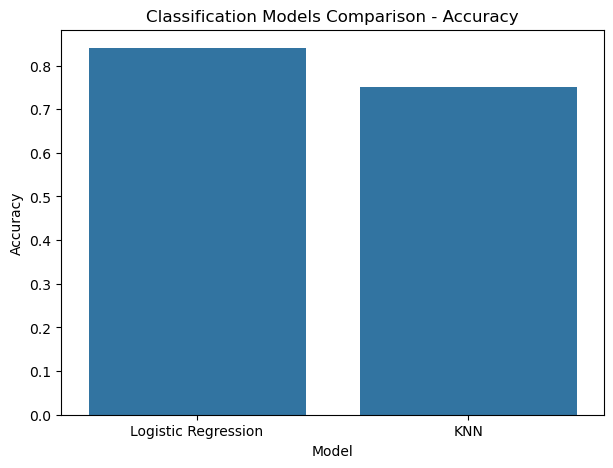

In [52]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=classification_results,
    x="Model",
    y="Accuracy"
)

plt.title("Classification Models Comparison - Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()

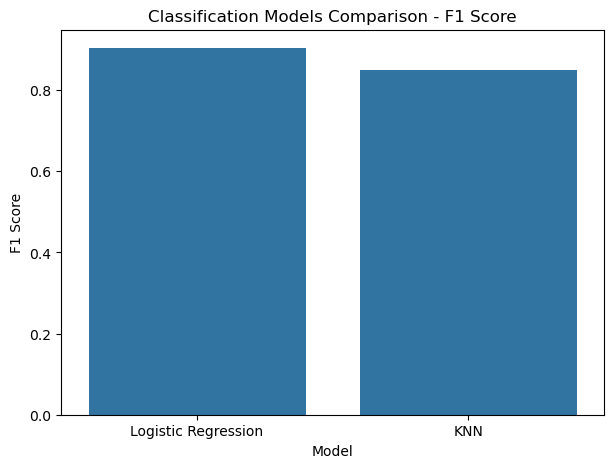

In [53]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=classification_results,
    x="Model",
    y="F1 Score"
)

plt.title("Classification Models Comparison - F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.show()

In [54]:
best_classification_model = classification_results.loc[
    classification_results["F1 Score"].idxmax()
]

print("Best Classification Model:")
print(best_classification_model)

Best Classification Model:
Model        Logistic Regression
Accuracy                    0.84
Precision               0.842697
Recall                  0.974026
F1 Score                0.903614
Name: 0, dtype: object
